# **Pembelajaran Tanpa Pengawasan (Unsupervised Learning) & Preprocessing Data**
Catatan ini menyajikan implementasi praktis dan penjelasan konseptual mengenai tahapan prapemrosesan data (Preprocessing & Scaling) serta penerapan algoritma Unsupervised Learning. Eksplorasi ini mencakup teknik reduksi dimensi (PCA, t-SNE) dan algoritma pengelompokan (K-Means, Hierarchical Clustering, dan DBSCAN).

Bagian 1: Prapemrosesan & Penskalaan Data (Data Scaling)
Banyak algoritma machine learning (seperti SVM dan Neural Networks) sangat sensitif terhadap skala fitur dari data masukan. Oleh karena itu, prapemrosesan data mutlak diperlukan. Terdapat empat metode penskalaan utama yang umum digunakan:

StandardScaler: Menstandarisasi fitur dengan menghilangkan rata-rata (sehingga mean = 0) dan membagi dengan standar deviasi (sehingga variansi = 1).

MinMaxScaler: Mengubah nilai fitur ke dalam rentang spesifik, umumnya antara 0 hingga 1.

RobustScaler: Bekerja mirip dengan StandardScaler, namun menggunakan median dan rentang interkuartil (IQR) sehingga jauh lebih tangguh terhadap keberadaan data pencilan (outliers).

Normalizer: Melakukan penskalaan pada setiap baris sampel data (vektor) secara individual agar memiliki panjang Euclidean tepat 1. Sering diaplikasikan pada pemrosesan teks atau clustering spesifik.

In [21]:
# [1] Setup environment dan instalasi pustaka pendukung
!pip install mglearn seaborn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mglearn

# Memuat modul scikit-learn untuk pemodelan dan prapemrosesan
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer, load_digits, make_moons, make_blobs
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.svm import SVC
from scipy.cluster.hierarchy import dendrogram, linkage

# Konfigurasi visualisasi
%matplotlib inline
sns.set_theme(style="whitegrid")
print("Semua pustaka utama untuk Unsupervised Learning berhasil dimuat.")

Semua pustaka utama untuk Unsupervised Learning berhasil dimuat.


# **Demonstrasi Efek Penskalaan & Identifikasi Kebocoran Data (Data Leakage)**
Sangat penting untuk diingat bahwa proses fitting skaler hanya boleh dilakukan pada data latih. Data uji hanya boleh di-transform menggunakan parameter yang dipelajari dari data latih untuk mencegah terjadinya kebocoran informasi (data leakage).

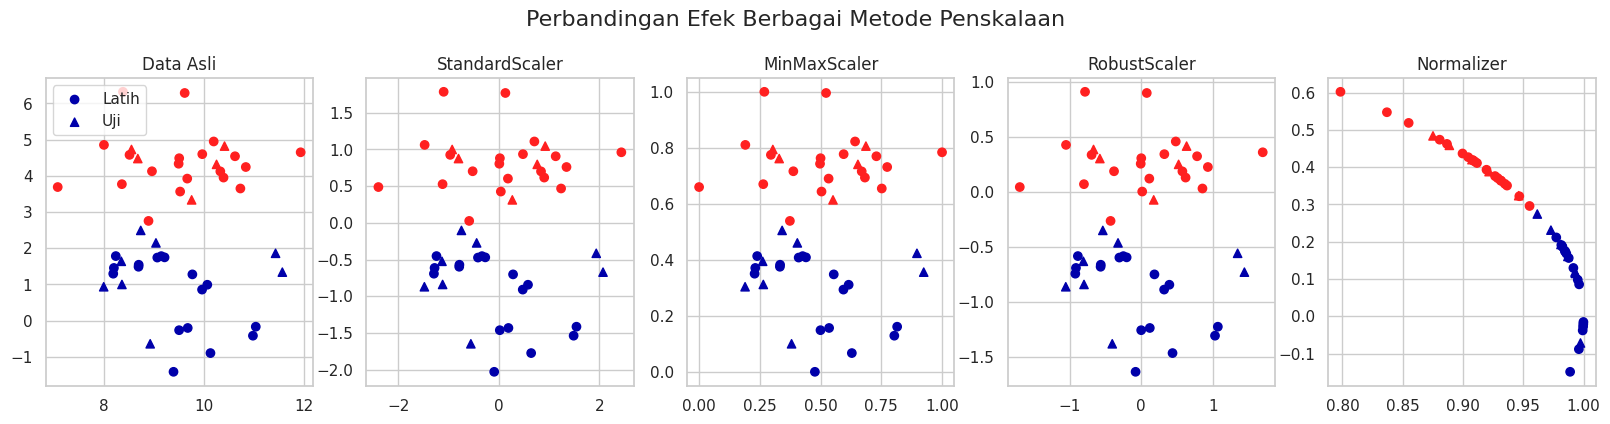

Akurasi Model SVM Tanpa Penskalaan: 0.9441
Akurasi Model SVM dengan MinMaxScaler: 0.9650


In [22]:
# 1. Visualisasi Perbandingan Efek Skaler
X_sintetis, y_sintetis = make_blobs(n_samples=50, centers=2, random_state=4, cluster_std=1)
X_latih, X_uji, y_latih, y_uji = train_test_split(X_sintetis, y_sintetis, random_state=5, test_size=0.25)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].scatter(X_latih[:, 0], X_latih[:, 1], c=y_latih, cmap=mglearn.cm2, label="Latih")
axes[0].scatter(X_uji[:, 0], X_uji[:, 1], c=y_uji, cmap=mglearn.cm2, marker='^', label="Uji")
axes[0].set_title("Data Asli")
axes[0].legend(loc="upper left")

daftar_skaler = [StandardScaler(), MinMaxScaler(), RobustScaler(), Normalizer()]
nama_skaler = ["StandardScaler", "MinMaxScaler", "RobustScaler", "Normalizer"]

for ax, skaler_uji, nama in zip(axes[1:], daftar_skaler, nama_skaler):
    X_latih_skala = skaler_uji.fit_transform(X_latih)
    X_uji_skala = skaler_uji.transform(X_uji)
    ax.scatter(X_latih_skala[:, 0], X_latih_skala[:, 1], c=y_latih, cmap=mglearn.cm2)
    ax.scatter(X_uji_skala[:, 0], X_uji_skala[:, 1], c=y_uji, cmap=mglearn.cm2, marker='^')
    ax.set_title(nama)

plt.suptitle("Perbandingan Efek Berbagai Metode Penskalaan", y=1.05, fontsize=16)
plt.show()

# 2. Demonstrasi Kebocoran Data (Data Leakage)
X_kebocoran, _ = make_blobs(n_samples=50, centers=5, random_state=4, cluster_std=2)
X_latih_k, X_uji_k = train_test_split(X_kebocoran, random_state=5, test_size=0.1)

# Praktik yang Benar (Konsisten)
skaler_konsisten = MinMaxScaler()
X_train_benar = skaler_konsisten.fit_transform(X_latih_k)
X_uji_benar = skaler_konsisten.transform(X_uji_k)

# Praktik yang Salah (Menyebabkan Data Leakage)
skaler_independen = MinMaxScaler()
X_train_salah = skaler_independen.fit_transform(X_latih_k)
X_uji_salah = skaler_independen.fit_transform(X_uji_k) # Fatal: Melakukan fit ulang pada data uji

# 3. Dampak Penskalaan terhadap Performa Model (Studi Kasus SVM)
kanker = load_breast_cancer()
X_latih_kan, X_uji_kan, y_latih_kan, y_uji_kan = train_test_split(kanker.data, kanker.target, random_state=0)

# Evaluasi SVM Tanpa Penskalaan
svm_tanpa_skala = SVC(C=100).fit(X_latih_kan, y_latih_kan)
print(f"Akurasi Model SVM Tanpa Penskalaan: {svm_tanpa_skala.score(X_uji_kan, y_uji_kan):.4f}")

# Evaluasi SVM Dengan Penskalaan
skaler_kanker = MinMaxScaler()
X_latih_scaled = skaler_kanker.fit_transform(X_latih_kan)
X_uji_scaled = skaler_kanker.transform(X_uji_kan)

svm_dengan_skala = SVC(C=100).fit(X_latih_scaled, y_latih_kan)
print(f"Akurasi Model SVM dengan MinMaxScaler: {svm_dengan_skala.score(X_uji_scaled, y_uji_kan):.4f}")

# **Bagian 2: Reduksi Dimensi & Ekstraksi Fitur (PCA vs t-SNE)**
Reduksi dimensi digunakan untuk menyederhanakan data berdimensi tinggi agar dapat divisualisasikan atau diproses lebih efisien.

PCA (Principal Component Analysis): Mereduksi jumlah fitur dengan mencari arah komponen utama yang memiliki variansi terbesar.

t-SNE (t-Distributed Stochastic Neighbor Embedding): Teknik reduksi dimensi non-linier (manifold learning) yang sangat efektif untuk visualisasi. Metode ini memetakan titik yang berdekatan di dimensi tinggi agar tetap berdekatan di representasi dimensi rendah.

Dimensi Kanker Sebelum Reduksi: (569, 30)
Dimensi Kanker Setelah Reduksi: (569, 2)


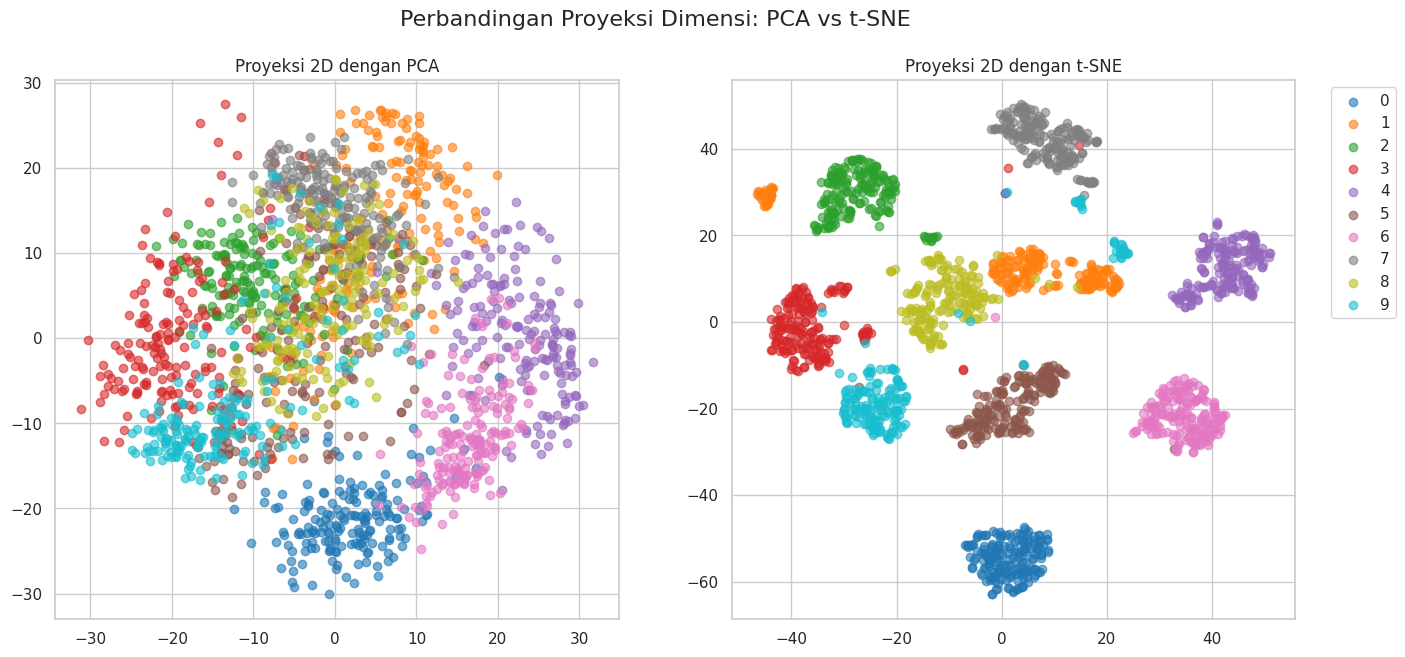

In [23]:
# Mereduksi dimensi dataset Kanker dari 30 fitur menjadi 2 fitur menggunakan PCA
skaler_std = StandardScaler()
X_kanker_skala = skaler_std.fit_transform(kanker.data)

pca_kanker = PCA(n_components=2)
X_kanker_pca = pca_kanker.fit_transform(X_kanker_skala)
print(f"Dimensi Kanker Sebelum Reduksi: {X_kanker_skala.shape}")
print(f"Dimensi Kanker Setelah Reduksi: {X_kanker_pca.shape}")

# Komparasi Visual: PCA vs t-SNE pada Dataset Citra Digits
dataset_digits = load_digits()

# Proyeksi PCA
pca_dig = PCA(n_components=2)
X_digits_pca = pca_dig.fit_transform(dataset_digits.data)

# Proyeksi t-SNE
tsne_dig = TSNE(random_state=42)
X_digits_tsne = tsne_dig.fit_transform(dataset_digits.data)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
warna_kelas = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
               "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

# Plot Hasil PCA
for i in range(10):
    axes[0].scatter(X_digits_pca[dataset_digits.target == i, 0], X_digits_pca[dataset_digits.target == i, 1],
                    color=warna_kelas[i], label=str(i), alpha=0.6)
axes[0].set_title("Proyeksi 2D dengan PCA")

# Plot Hasil t-SNE
for i in range(10):
    axes[1].scatter(X_digits_tsne[dataset_digits.target == i, 0], X_digits_tsne[dataset_digits.target == i, 1],
                    color=warna_kelas[i], label=str(i), alpha=0.6)
axes[1].set_title("Proyeksi 2D dengan t-SNE")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("Perbandingan Proyeksi Dimensi: PCA vs t-SNE", y=0.98, fontsize=16)
plt.show()

# **Bagian 3: Algoritma Pengelompokan (Clustering)**
Algoritma clustering bertujuan untuk mempartisi sekumpulan data ke dalam kelompok-kelompok homogen tanpa adanya label target aktual (ground truth).

K-Means: Mengelompokkan titik data berdasarkan kedekatan geometris (jarak Euclidean) menuju pusat klaster (centroid). Tidak efektif untuk data dengan bentuk geometris yang kompleks.

Agglomerative Clustering: Menggunakan pendekatan hierarki (bottom-up) untuk menggabungkan klaster-klaster kecil menjadi klaster besar. Proses ini divisualisasikan melalui Dendrogram.

DBSCAN: Pengelompokan berbasis kepadatan area lokal. Sangat tangguh dalam mengidentifikasi anomali (outliers) dan mendeteksi klaster dengan struktur atau bentuk yang non-linear.

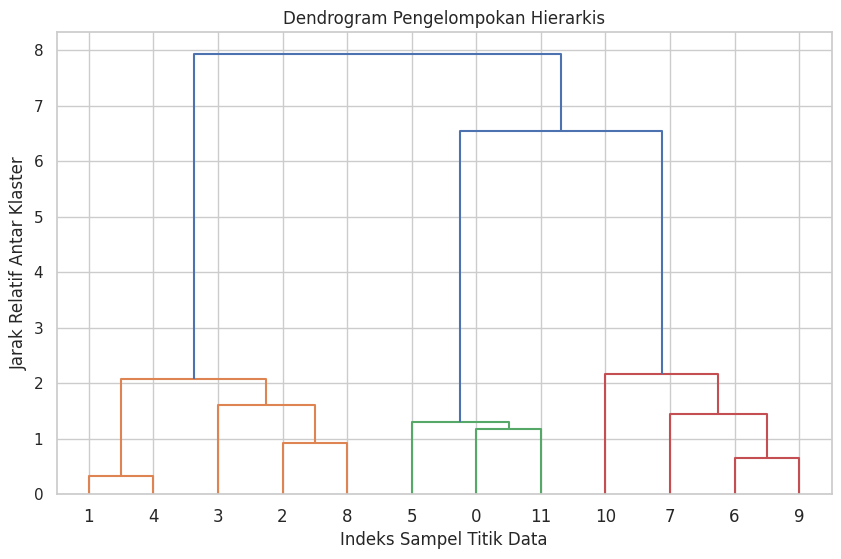

In [24]:
# 1. K-Means Clustering pada dataset konvensional
X_blobs, _ = make_blobs(random_state=1, n_samples=200)
kmeans = KMeans(n_clusters=3, random_state=0)
labels_kmeans = kmeans.fit_predict(X_blobs)

# 2. Kegagalan K-Means pada dataset melengkung (Moons)
X_moons, y_moons = make_moons(n_samples=200, noise=0.05, random_state=0)
kmeans_moons = KMeans(n_clusters=2, random_state=0).fit(X_moons)

# 3. Representasi Dendrogram dari Agglomerative Clustering
X_hierarki, _ = make_blobs(random_state=0, n_samples=12)
matriks_jarak_ward = linkage(X_hierarki, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(matriks_jarak_ward)
plt.title("Dendrogram Pengelompokan Hierarkis")
plt.xlabel("Indeks Sampel Titik Data")
plt.ylabel("Jarak Relatif Antar Klaster")
plt.show()

# 4. Solusi DBSCAN untuk Dataset Melengkung (Moons)
dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan = dbscan_moons.fit_predict(X_moons)

# **Bagian 4: Evaluasi Performa Algoritma Clustering**
Berbeda dengan model klasifikasi, mengukur metrik keberhasilan clustering memiliki tantangan tersendiri. Beberapa metrik yang umum diaplikasikan adalah:

Adjusted Rand Index (ARI): Membandingkan kecocokan label hasil prediksi klaster dengan label ground truth (jika tersedia). Skor 1 menandakan pembagian klaster yang sempurna.

Silhouette Score: Mengukur kedekatan elemen dalam satu klaster yang sama dan jaraknya dengan elemen di klaster lain. Tidak memerlukan label ground truth.

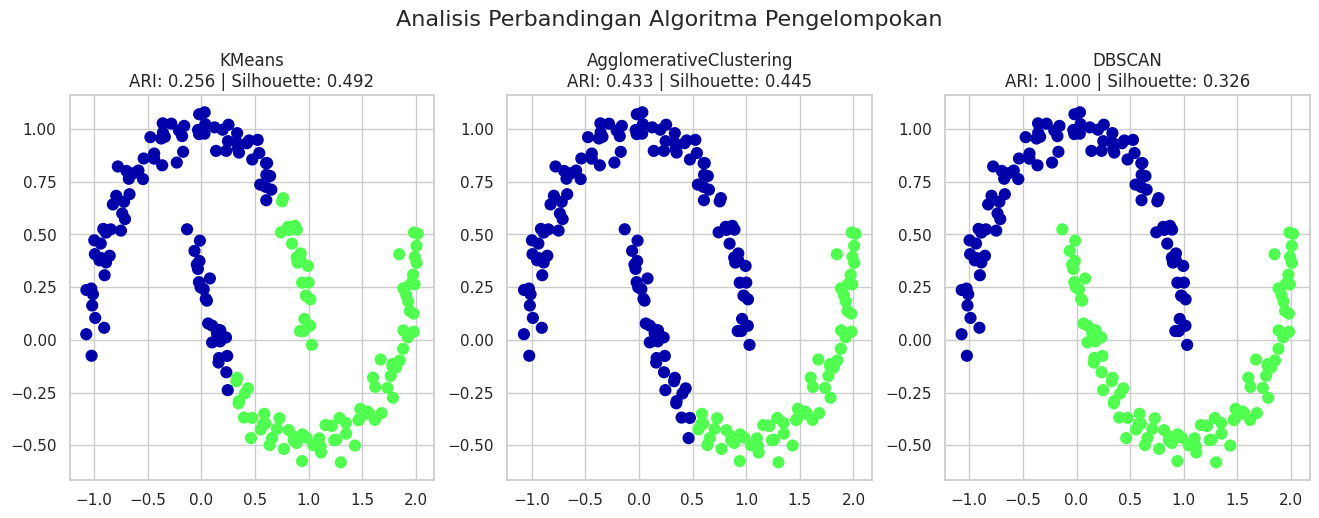

In [25]:
# Komparasi Evaluasi Metrik untuk ketiga Algoritma pada dataset Moons
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

daftar_algoritma = [
    KMeans(n_clusters=2, random_state=0),
    AgglomerativeClustering(n_clusters=2),
    DBSCAN(eps=0.2, min_samples=5)
]

for ax, algoritma in zip(axes, daftar_algoritma):
    prediksi_klaster = algoritma.fit_predict(X_moons)
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=prediksi_klaster, cmap=mglearn.cm3, s=60)

    # Perhitungan Skor Metrik Evaluasi
    skor_ari = adjusted_rand_score(y_moons, prediksi_klaster)
    skor_silhouette = silhouette_score(X_moons, prediksi_klaster)

    ax.set_title(f"{algoritma.__class__.__name__}\nARI: {skor_ari:.3f} | Silhouette: {skor_silhouette:.3f}")

plt.suptitle("Analisis Perbandingan Algoritma Pengelompokan", y=1.05, fontsize=16)
plt.show()